In [1]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================================
# CELL 2: LOAD DATASET
# ============================================================

df = pd.read_csv("crop_recommendation.csv")

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (6596, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,24,128,196,22.750888,90.694892,5.521467,110.431786,apple
1,7,144,197,23.849401,94.348150,6.133221,114.051249,apple
2,14,128,205,22.608010,94.589006,6.226290,116.039659,apple
3,8,120,201,21.186674,91.134357,6.321152,122.233323,apple
4,20,129,201,23.410447,91.699133,5.587906,116.077793,apple


In [3]:
# ============================================================
# FIGURE 2: DATASET BEFORE PREPROCESSING
# ============================================================

print("Dataset Before Preprocessing")

display(df.head(5))

Dataset Before Preprocessing


,N,P,K,temperature,humidity,ph,rainfall,label
0,24,128,196,22.750888,90.694892,5.521467,110.431786,apple
1,7,144,197,23.849401,94.348150,6.133221,114.051249,apple
2,14,128,205,22.608010,94.589006,6.226290,116.039659,apple
3,8,120,201,21.186674,91.134357,6.321152,122.233323,apple
4,20,129,201,23.410447,91.699133,5.587906,116.077793,apple


In [4]:
# ============================================================
# CELL 4: FEATURE ENGINEERING
# ============================================================

data = df.copy()

# NPK total
data["NPK_sum"] = (
    data["N"] +
    data["P"] +
    data["K"]
)

# NPK ratio
data["NPK_ratio"] = (
    data["N"] /
    (data["P"] + data["K"] + 1)
)

# Temperature × Humidity
data["temp_humidity"] = (
    data["temperature"] *
    data["humidity"]
)

# Rainfall × Temperature
data["rain_temp"] = (
    data["rainfall"] *
    data["temperature"]
)

# pH squared
data["ph_squared"] = (
    data["ph"] ** 2
)

# Log-transformed rainfall
data["rainfall_log"] = (
    np.log1p(data["rainfall"])
)

print("Feature engineering completed!")
print("New Dataset Shape:", data.shape)

display(data.head(5))

Feature engineering completed!
New Dataset Shape: (6596, 14)


,N,P,K,temperature,humidity,ph,rainfall,label,NPK_sum,NPK_ratio,temp_humidity,rain_temp,ph_squared,rainfall_log
0,24,128,196,22.750888,90.694892,5.521467,110.431786,apple,348,0.073846,2063.389312,2512.421169,30.486598,4.713413
1,7,144,197,23.849401,94.348150,6.133221,114.051249,apple,348,0.020468,2250.146900,2720.054029,37.616395,4.745378
2,14,128,205,22.608010,94.589006,6.226290,116.039659,apple,347,0.041916,2138.469182,2623.425750,38.766682,4.762513
3,8,120,201,21.186674,91.134357,6.321152,122.233323,apple,329,0.024845,1930.833927,2589.717590,39.956965,4.814079
4,20,129,201,23.410447,91.699133,5.587906,116.077793,apple,350,0.060423,2146.717698,2717.433030,31.224693,4.762839


In [5]:
# ============================================================
# FIGURE 3: DATASET AFTER PREPROCESSING
# ============================================================

print("Dataset After Preprocessing")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)

display(data.head(5))

Dataset After Preprocessing


,N,P,K,temperature,humidity,ph,rainfall,label,NPK_sum,NPK_ratio,temp_humidity,rain_temp,ph_squared,rainfall_log
0,24,128,196,22.750888,90.694892,5.521467,110.431786,apple,348,0.073846,2063.389312,2512.421169,30.486598,4.713413
1,7,144,197,23.849401,94.348150,6.133221,114.051249,apple,348,0.020468,2250.146900,2720.054029,37.616395,4.745378
2,14,128,205,22.608010,94.589006,6.226290,116.039659,apple,347,0.041916,2138.469182,2623.425750,38.766682,4.762513
3,8,120,201,21.186674,91.134357,6.321152,122.233323,apple,329,0.024845,1930.833927,2589.717590,39.956965,4.814079
4,20,129,201,23.410447,91.699133,5.587906,116.077793,apple,350,0.060423,2146.717698,2717.433030,31.224693,4.762839


In [6]:
# ============================================================
# CELL 6: DEFINE FEATURES AND TARGET
# ============================================================

X = data.drop("label", axis=1)

y = data["label"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature Shape: (6596, 13)
Target Shape: (6596,)

Features:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'NPK_sum', 'NPK_ratio', 'temp_humidity', 'rain_temp', 'ph_squared', 'rainfall_log']


In [7]:
# ============================================================
# CELL 7: LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Number of Classes:", len(label_encoder.classes_))

print("\nClasses:")
print(label_encoder.classes_)

Number of Classes: 51

Classes:
['apple' 'banana' 'barley' 'bitter_gourd' 'blackgram' 'blackpepper'
 'bottle_gourd' 'brinjal' 'cabbage' 'cardamom' 'cauliflower' 'chickpea'
 'coconut' 'coffee' 'coriander' 'cotton' 'cucumber' 'drumstick' 'garlic'
 'grapes' 'horsegram' 'jackfruit' 'jute' 'kidneybeans' 'lentil' 'maize'
 'mango' 'mothbeans' 'mungbean' 'muskmelon' 'okra' 'onion' 'orange'
 'papaya' 'pigeonpeas' 'pineapple' 'pomegranate' 'potato' 'pumpkin'
 'radish' 'ragi' 'rapeseed' 'rice' 'sorghum' 'soybean' 'sunflower'
 'sweet_potato' 'tomato' 'turmeric' 'watermelon' 'wheat']


In [8]:
# ============================================================
# CELL 8: STRATIFIED 80/20 TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

print("\nTraining Percentage:",
      f"{len(X_train) / len(X) * 100:.2f}%")

print("Testing Percentage:",
      f"{len(X_test) / len(X) * 100:.2f}%")

Training Samples: 5276
Testing Samples : 1320

Training Percentage: 79.99%
Testing Percentage: 20.01%


In [9]:
# ============================================================
# CELL 9: TRAIN-VALIDATION SPLIT
# ============================================================

X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training Samples  :", X_train_main.shape[0])
print("Validation Samples:", X_val.shape[0])
print("Test Samples      :", X_test.shape[0])

Training Samples  : 4220
Validation Samples: 1056
Test Samples      : 1320


In [10]:
# ============================================================
# CELL 10: SMOTE - TRAINING DATA ONLY
# ============================================================

from imblearn.over_sampling import SMOTE

# Use fewer neighbors because some classes have very few samples
smote = SMOTE(
    random_state=42,
    k_neighbors=2
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_main,
    y_train_main
)

print("Before SMOTE:", X_train_main.shape)
print("After SMOTE :", X_train_smote.shape)

print("\nSMOTE completed successfully!")

Before SMOTE: (4220, 13)
After SMOTE : (15045, 13)

SMOTE completed successfully!


In [11]:
# ============================================================
# CELL 11: RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)

# Create model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train ONLY on SMOTE training data
rf_model.fit(
    X_train_smote,
    y_train_smote
)

# Final prediction on untouched test data
y_pred_rf = rf_model.predict(X_test)

# Accuracy
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

print("\nRandom Forest Accuracy:", accuracy_rf)
print(
    "Random Forest Accuracy:",
    accuracy_rf * 100,
    "%"
)

# Classification report
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=label_encoder.classes_
    )
)

RANDOM FOREST

Random Forest Accuracy: 0.9946969696969697
Random Forest Accuracy: 99.46969696969697 %

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
      barley       1.00      1.00      1.00        38
bitter_gourd       1.00      1.00      1.00         2
   blackgram       1.00      0.95      0.97        20
 blackpepper       1.00      1.00      1.00        14
bottle_gourd       1.00      1.00      1.00         2
     brinjal       1.00      1.00      1.00         9
     cabbage       1.00      1.00      1.00         4
    cardamom       1.00      1.00      1.00         8
 cauliflower       1.00      1.00      1.00         4
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      0.95      0.97        20
   coriander       1.00      1.00      1.00        38
      co

In [12]:
# ============================================================
# CELL 12: XGBOOST
# ============================================================

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

print("=" * 60)
print("XGBOOST")
print("=" * 60)

# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

# Train ONLY on SMOTE training data
xgb_model.fit(
    X_train_smote,
    y_train_smote
)

# Final prediction on untouched test data
y_pred_xgb = xgb_model.predict(X_test)

# Accuracy
accuracy_xgb = accuracy_score(
    y_test,
    y_pred_xgb
)

print("\nXGBoost Accuracy:", accuracy_xgb)
print(
    "XGBoost Accuracy:",
    accuracy_xgb * 100,
    "%"
)

# Classification Report
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=label_encoder.classes_
    )
)

XGBOOST

XGBoost Accuracy: 0.9962121212121212
XGBoost Accuracy: 99.62121212121212 %

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
      barley       1.00      1.00      1.00        38
bitter_gourd       1.00      1.00      1.00         2
   blackgram       1.00      0.95      0.97        20
 blackpepper       1.00      1.00      1.00        14
bottle_gourd       1.00      1.00      1.00         2
     brinjal       1.00      1.00      1.00         9
     cabbage       1.00      1.00      1.00         4
    cardamom       1.00      1.00      1.00         8
 cauliflower       1.00      1.00      1.00         4
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
   coriander       1.00      1.00      1.00        38
      cotton       1.00   

In [13]:
# ============================================================
# CELL 13: CATBOOST
# ============================================================

from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

print("=" * 60)
print("CATBOOST")
print("=" * 60)

# Create CatBoost model
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    random_seed=42,
    verbose=0
)

# Train ONLY on SMOTE training data
cat_model.fit(
    X_train_smote,
    y_train_smote
)

# Final prediction on untouched test data
y_pred_cat = cat_model.predict(X_test)

# CatBoost may return shape (samples, 1)
y_pred_cat = y_pred_cat.flatten()

# Accuracy
accuracy_cat = accuracy_score(
    y_test,
    y_pred_cat
)

print("\nCatBoost Accuracy:", accuracy_cat)
print(
    "CatBoost Accuracy:",
    accuracy_cat * 100,
    "%"
)

# Classification Report
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_cat,
        target_names=label_encoder.classes_
    )
)

CATBOOST

CatBoost Accuracy: 0.9954545454545455
CatBoost Accuracy: 99.54545454545455 %

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
      barley       1.00      1.00      1.00        38
bitter_gourd       1.00      1.00      1.00         2
   blackgram       1.00      0.95      0.97        20
 blackpepper       1.00      1.00      1.00        14
bottle_gourd       1.00      1.00      1.00         2
     brinjal       1.00      1.00      1.00         9
     cabbage       1.00      1.00      1.00         4
    cardamom       1.00      1.00      1.00         8
 cauliflower       1.00      1.00      1.00         4
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
   coriander       1.00      1.00      1.00        38
      cotton       1.00

In [14]:
# ============================================================
# CELL 14: TABNET
# No Test Data Leakage
# ============================================================

from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

print("=" * 60)
print("TABNET")
print("=" * 60)

# ------------------------------------------------------------
# 1. Convert data to NumPy
# ------------------------------------------------------------

X_train_tab = X_train_smote.values.astype(np.float32)
y_train_tab = np.array(y_train_smote)

X_val_tab = X_val.values.astype(np.float32)
y_val_tab = np.array(y_val)

X_test_tab = X_test.values.astype(np.float32)

# ------------------------------------------------------------
# 2. Create TabNet Model
# ------------------------------------------------------------

tabnet_model = TabNetClassifier(
    seed=42,
    verbose=10
)

# ------------------------------------------------------------
# 3. Train TabNet
# ------------------------------------------------------------
# IMPORTANT:
# Training data = SMOTE training data
# Validation data = X_val
# Test data is NOT used during training

tabnet_model.fit(
    X_train=X_train_tab,
    y_train=y_train_tab,

    eval_set=[
        (X_train_tab, y_train_tab),
        (X_val_tab, y_val_tab)
    ],

    eval_name=[
        "train",
        "validation"
    ],

    eval_metric=[
        "accuracy"
    ],

    max_epochs=100,
    patience=15,
    batch_size=256,
    virtual_batch_size=128
)

# ------------------------------------------------------------
# 4. Final Prediction on Unseen Test Data
# ------------------------------------------------------------

y_pred_tabnet = tabnet_model.predict(X_test_tab)

# Convert shape if necessary
y_pred_tabnet = np.array(y_pred_tabnet).reshape(-1)

# ------------------------------------------------------------
# 5. Accuracy
# ------------------------------------------------------------

accuracy_tabnet = accuracy_score(
    y_test,
    y_pred_tabnet
)

print("\nTabNet Accuracy:", accuracy_tabnet)

print(
    "TabNet Accuracy:",
    accuracy_tabnet * 100,
    "%"
)

# ------------------------------------------------------------
# 6. Classification Report
# ------------------------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_tabnet,
        target_names=label_encoder.classes_
    )
)

TABNET


c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 3.13943 | train_accuracy: 0.03084 | validation_accuracy: 0.02462 |  0:00:03s
epoch 10 | loss: 0.20398 | train_accuracy: 0.94616 | validation_accuracy: 0.93561 |  0:00:38s
epoch 20 | loss: 0.1485  | train_accuracy: 0.94942 | validation_accuracy: 0.9375  |  0:01:12s
epoch 30 | loss: 0.12653 | train_accuracy: 0.97135 | validation_accuracy: 0.95265 |  0:01:46s
epoch 40 | loss: 0.08993 | train_accuracy: 0.98637 | validation_accuracy: 0.97159 |  0:02:20s
epoch 50 | loss: 0.07063 | train_accuracy: 0.98278 | validation_accuracy: 0.9697  |  0:02:53s
epoch 60 | loss: 0.05748 | train_accuracy: 0.99242 | validation_accuracy: 0.97633 |  0:03:27s

Early stopping occurred at epoch 67 with best_epoch = 52 and best_validation_accuracy = 0.97633


c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



TabNet Accuracy: 0.9757575757575757
TabNet Accuracy: 97.57575757575758 %

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
      barley       0.97      1.00      0.99        38
bitter_gourd       1.00      1.00      1.00         2
   blackgram       0.87      1.00      0.93        20
 blackpepper       1.00      1.00      1.00        14
bottle_gourd       1.00      1.00      1.00         2
     brinjal       0.82      1.00      0.90         9
     cabbage       1.00      1.00      1.00         4
    cardamom       1.00      1.00      1.00         8
 cauliflower       1.00      1.00      1.00         4
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
   coriander       1.00      1.00      1.00        38
      cotton       1.00      1.00   

In [15]:
# ============================================================
# CELL 15: LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

# ------------------------------------------------------------
# 1. Create Scaler
# ------------------------------------------------------------

scaler = StandardScaler()

# Fit scaler ONLY on SMOTE training data
X_train_lr = scaler.fit_transform(X_train_smote)

# Transform validation/test data using the same scaler
X_val_lr = scaler.transform(X_val)
X_test_lr = scaler.transform(X_test)

# ------------------------------------------------------------
# 2. Create Logistic Regression Model
# ------------------------------------------------------------

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# ------------------------------------------------------------
# 3. Train ONLY on SMOTE training data
# ------------------------------------------------------------

logistic_model.fit(
    X_train_lr,
    y_train_smote
)

# ------------------------------------------------------------
# 4. Final Prediction on Untouched Test Data
# ------------------------------------------------------------

y_pred_lr = logistic_model.predict(
    X_test_lr
)

# ------------------------------------------------------------
# 5. Accuracy
# ------------------------------------------------------------

accuracy_lr = accuracy_score(
    y_test,
    y_pred_lr
)

print("\nLogistic Regression Accuracy:", accuracy_lr)

print(
    "Logistic Regression Accuracy:",
    accuracy_lr * 100,
    "%"
)

# ------------------------------------------------------------
# 6. Classification Report
# ------------------------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=label_encoder.classes_
    )
)

LOGISTIC REGRESSION

Logistic Regression Accuracy: 0.9477272727272728
Logistic Regression Accuracy: 94.77272727272728 %

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
      barley       0.95      0.95      0.95        38
bitter_gourd       1.00      1.00      1.00         2
   blackgram       0.91      1.00      0.95        20
 blackpepper       1.00      1.00      1.00        14
bottle_gourd       1.00      1.00      1.00         2
     brinjal       0.90      1.00      0.95         9
     cabbage       1.00      1.00      1.00         4
    cardamom       1.00      1.00      1.00         8
 cauliflower       1.00      1.00      1.00         4
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
   coriander       1.00      0.97      0.99 

In [16]:
# ============================================================
# CELL 16: EXPLAINABLE BOOSTING MACHINE (EBM)
# ============================================================

from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

print("=" * 60)
print("EXPLAINABLE BOOSTING MACHINE (EBM)")
print("=" * 60)

# ------------------------------------------------------------
# 1. Create EBM Model
# ------------------------------------------------------------

ebm_model = ExplainableBoostingClassifier(
    random_state=42,
    interactions=10
)

# ------------------------------------------------------------
# 2. Train ONLY on SMOTE training data
# ------------------------------------------------------------

ebm_model.fit(
    X_train_smote,
    y_train_smote
)

# ------------------------------------------------------------
# 3. Final Prediction on Untouched Test Data
# ------------------------------------------------------------

y_pred_ebm = ebm_model.predict(
    X_test
)

# ------------------------------------------------------------
# 4. Accuracy
# ------------------------------------------------------------

accuracy_ebm = accuracy_score(
    y_test,
    y_pred_ebm
)

print("\nEBM Accuracy:", accuracy_ebm)

print(
    "EBM Accuracy:",
    accuracy_ebm * 100,
    "%"
)

# ------------------------------------------------------------
# 5. Classification Report
# ------------------------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_ebm,
        target_names=label_encoder.classes_
    )
)

EXPLAINABLE BOOSTING MACHINE (EBM)


c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:1249: UserWarning: For multiclass we cannot currently visualize pairs and they will be stripped from the global explanations. Set interactions=0 to generate a fully interpretable glassbox model.
  warn(



EBM Accuracy: 0.9954545454545455
EBM Accuracy: 99.54545454545455 %

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
      barley       1.00      1.00      1.00        38
bitter_gourd       1.00      1.00      1.00         2
   blackgram       1.00      1.00      1.00        20
 blackpepper       1.00      1.00      1.00        14
bottle_gourd       1.00      1.00      1.00         2
     brinjal       1.00      1.00      1.00         9
     cabbage       1.00      1.00      1.00         4
    cardamom       1.00      1.00      1.00         8
 cauliflower       1.00      1.00      1.00         4
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
   coriander       1.00      1.00      1.00        38
      cotton       1.00      1.00      1.0

In [17]:
# ============================================================
# CELL 17: MODEL PERFORMANCE COMPARISON
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

print("=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)

# ------------------------------------------------------------
# 1. Store all model predictions
# ------------------------------------------------------------

model_predictions = {
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "CatBoost": y_pred_cat,
    "TabNet": y_pred_tabnet,
    "Logistic Regression": y_pred_lr,
    "EBM": y_pred_ebm
}

# ------------------------------------------------------------
# 2. Calculate Performance Metrics
# ------------------------------------------------------------

results = []

for model_name, predictions in model_predictions.items():

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    results.append([
        model_name,
        accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100
    ])

# ------------------------------------------------------------
# 3. Create Comparison Table
# ------------------------------------------------------------

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1-Score (%)"
    ]
)

# Sort by Accuracy
results_df = results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# 4. Display Table
# ------------------------------------------------------------

display(
    results_df.style
    .format({
        "Accuracy (%)": "{:.2f}",
        "Precision (%)": "{:.2f}",
        "Recall (%)": "{:.2f}",
        "F1-Score (%)": "{:.2f}"
    })
    .set_caption("Table: Performance Comparison of Six Machine Learning Models")
)

# ------------------------------------------------------------
# 5. Best Model
# ------------------------------------------------------------

best_model_name = results_df.iloc[0]["Model"]
best_accuracy = results_df.iloc[0]["Accuracy (%)"]

print("\nBest Performing Model:", best_model_name)
print(f"Best Accuracy: {best_accuracy:.2f}%")

MODEL PERFORMANCE COMPARISON


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,XGBoost,99.62,99.62,99.62,99.62
1,CatBoost,99.55,99.55,99.55,99.55
2,EBM,99.55,99.55,99.55,99.55
3,Random Forest,99.47,99.49,99.47,99.47
4,TabNet,97.58,97.72,97.58,97.57
5,Logistic Regression,94.77,94.75,94.77,94.69



Best Performing Model: XGBoost
Best Accuracy: 99.62%


CONFUSION MATRICES - ALL SIX MODELS


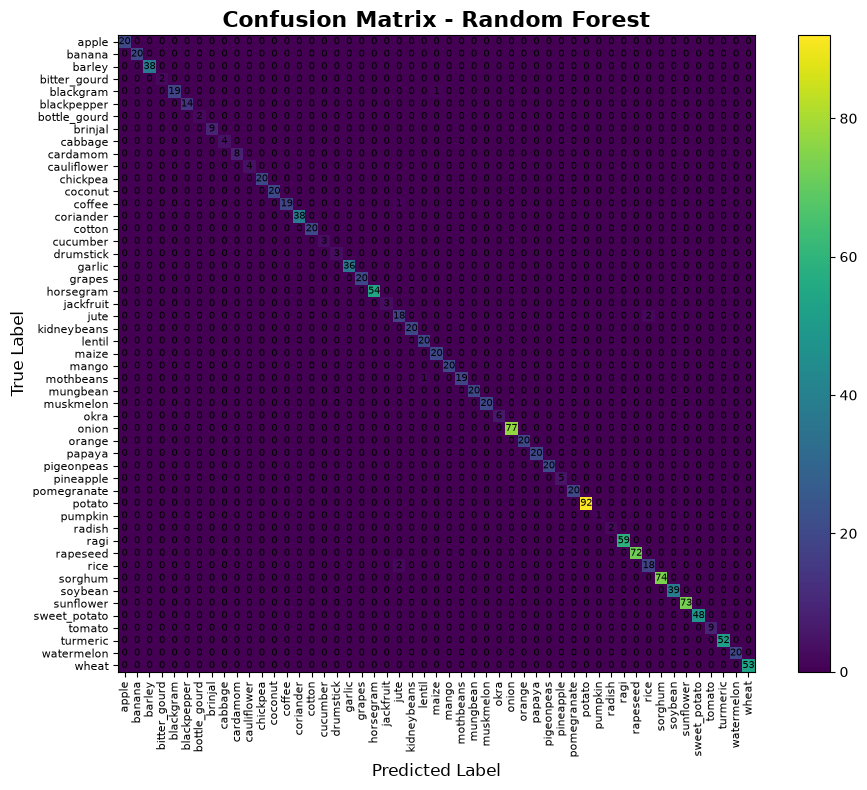

Saved: Confusion_Matrix_Random_Forest.png


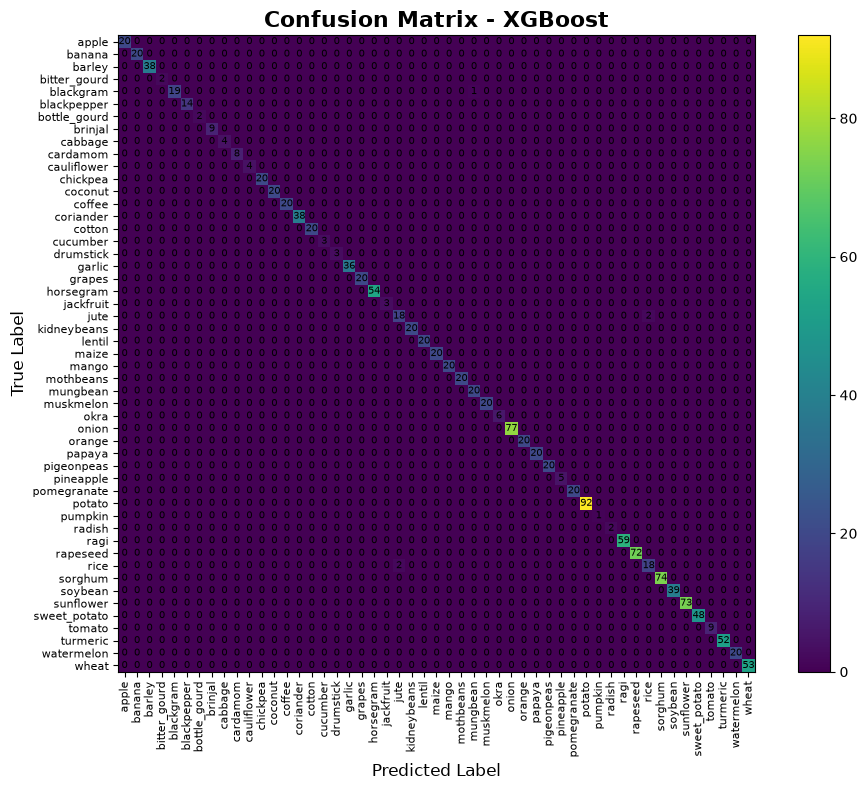

Saved: Confusion_Matrix_XGBoost.png


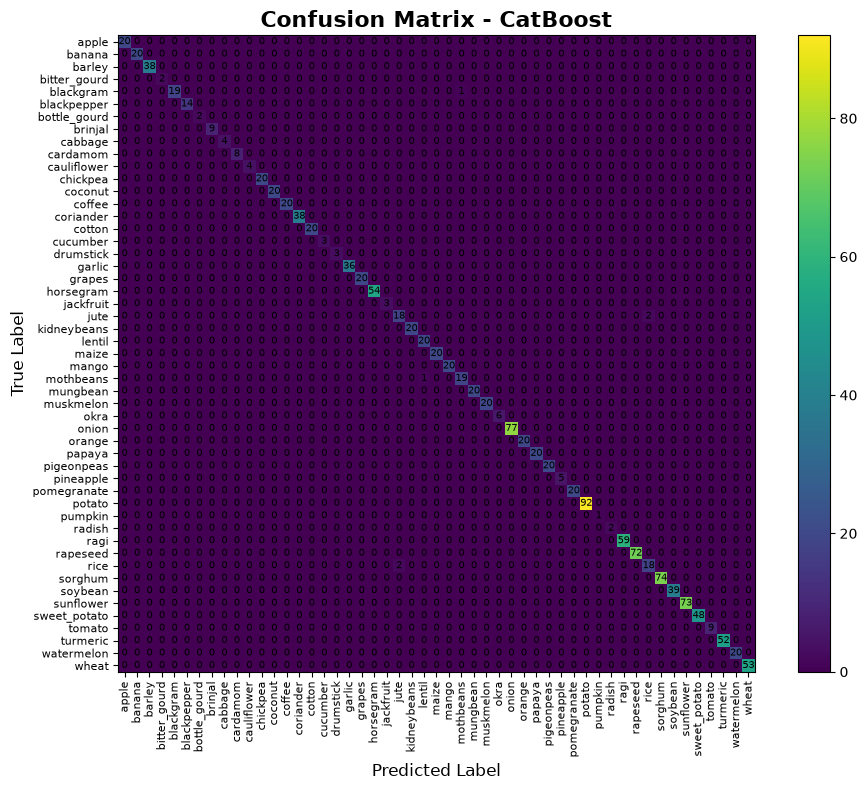

Saved: Confusion_Matrix_CatBoost.png


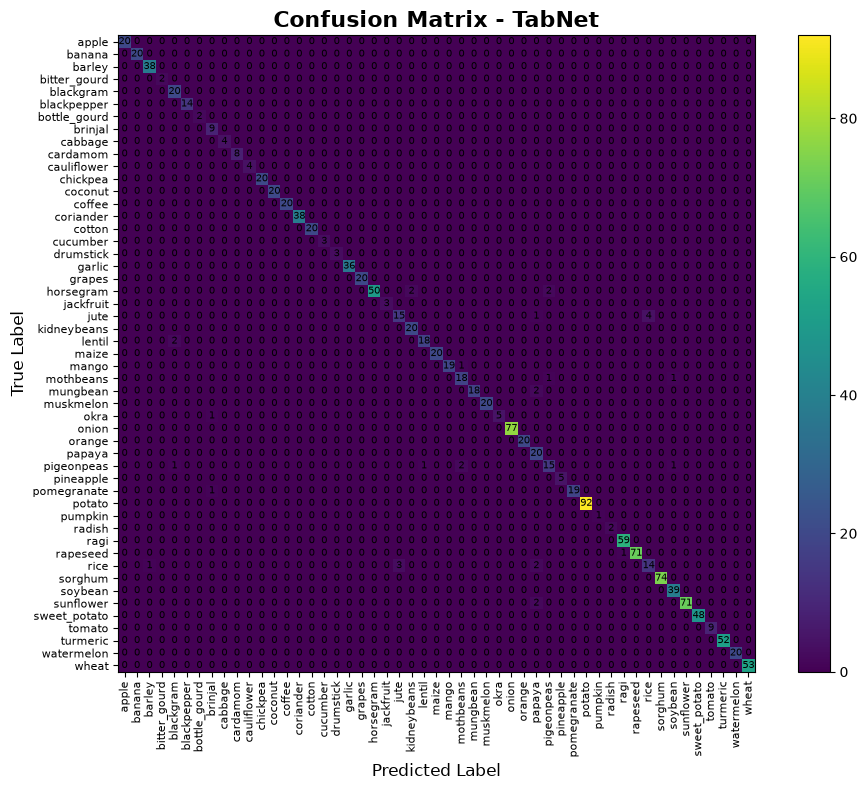

Saved: Confusion_Matrix_TabNet.png


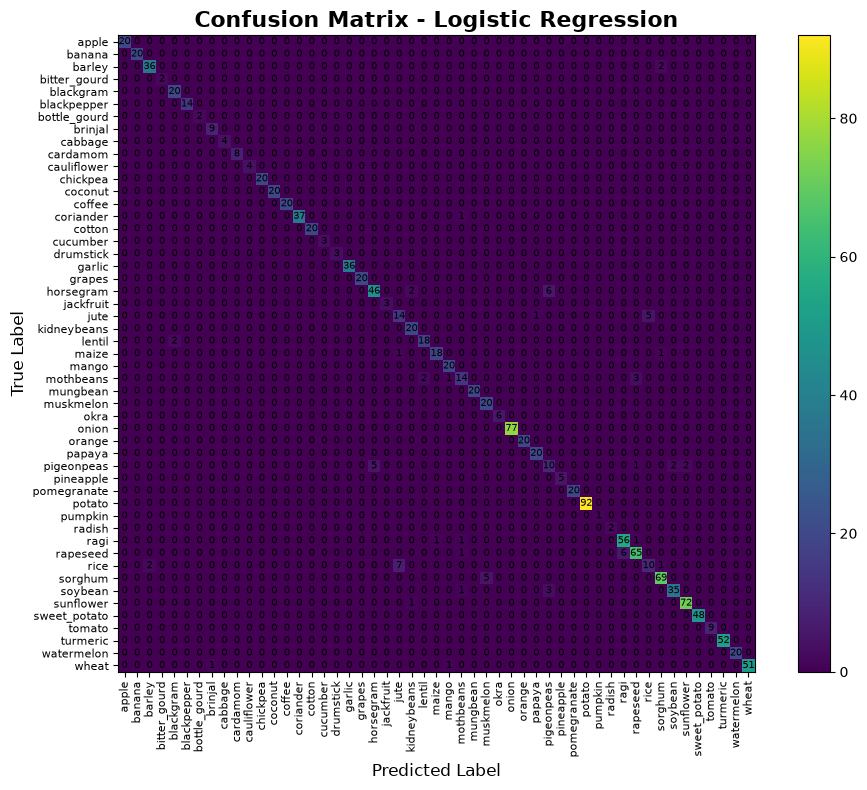

Saved: Confusion_Matrix_Logistic_Regression.png


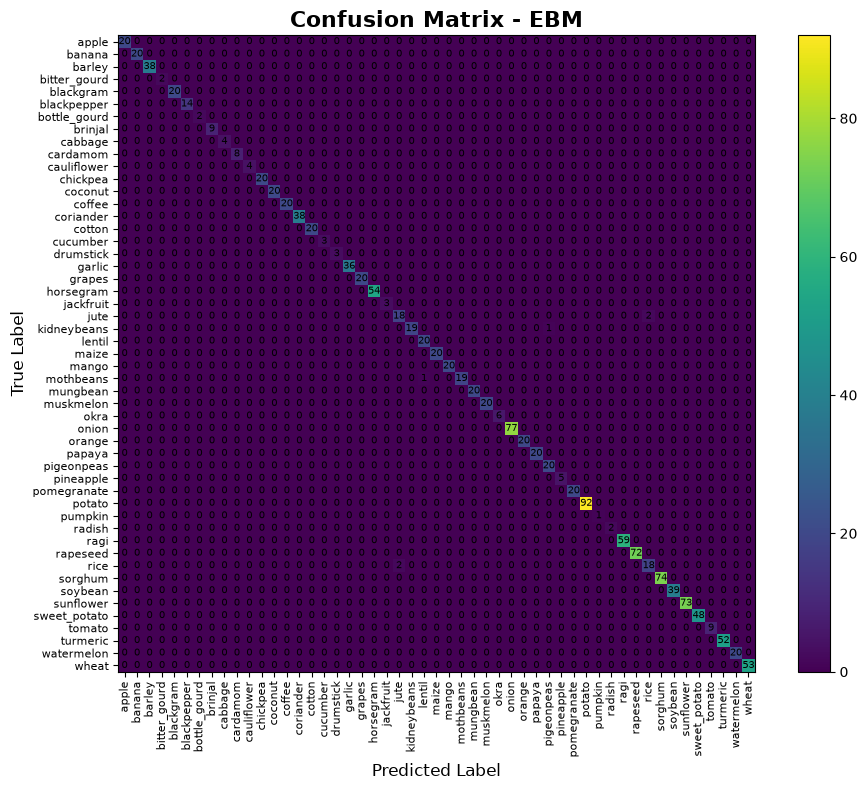

Saved: Confusion_Matrix_EBM.png

All six confusion matrices generated successfully!


In [18]:
# ============================================================
# CELL 18: CONFUSION MATRICES FOR ALL 6 MODELS
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("CONFUSION MATRICES - ALL SIX MODELS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Store predictions
# ------------------------------------------------------------

model_predictions = {
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "CatBoost": y_pred_cat,
    "TabNet": y_pred_tabnet,
    "Logistic Regression": y_pred_lr,
    "EBM": y_pred_ebm
}

# Class names
class_names = label_encoder.classes_

# ------------------------------------------------------------
# 2. Create confusion matrix for each model
# ------------------------------------------------------------

for model_name, predictions in model_predictions.items():

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(10, 8))

    plt.imshow(cm, interpolation="nearest")

    plt.title(
        f"Confusion Matrix - {model_name}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(
        "Predicted Label",
        fontsize=12
    )

    plt.ylabel(
        "True Label",
        fontsize=12
    )

    # --------------------------------------------------------
    # Add class labels
    # --------------------------------------------------------

    plt.xticks(
        np.arange(len(class_names)),
        class_names,
        rotation=90,
        fontsize=8
    )

    plt.yticks(
        np.arange(len(class_names)),
        class_names,
        fontsize=8
    )

    # --------------------------------------------------------
    # Add numbers inside cells
    # --------------------------------------------------------

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):

            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                fontsize=7
            )

    plt.colorbar()

    plt.tight_layout()

    # --------------------------------------------------------
    # Save each matrix separately
    # --------------------------------------------------------

    filename = (
        model_name
        .replace(" ", "_")
        .replace("-", "_")
    )

    plt.savefig(
        f"Confusion_Matrix_{filename}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Saved: Confusion_Matrix_{filename}.png"
    )

print("\nAll six confusion matrices generated successfully!")

PREDICTION CONFIDENCE DISTRIBUTION

Best-Performing Model: XGBoost

Number of Test Samples: 1320
Mean Confidence: 98.84%
Minimum Confidence: 10.03%
Maximum Confidence: 99.94%


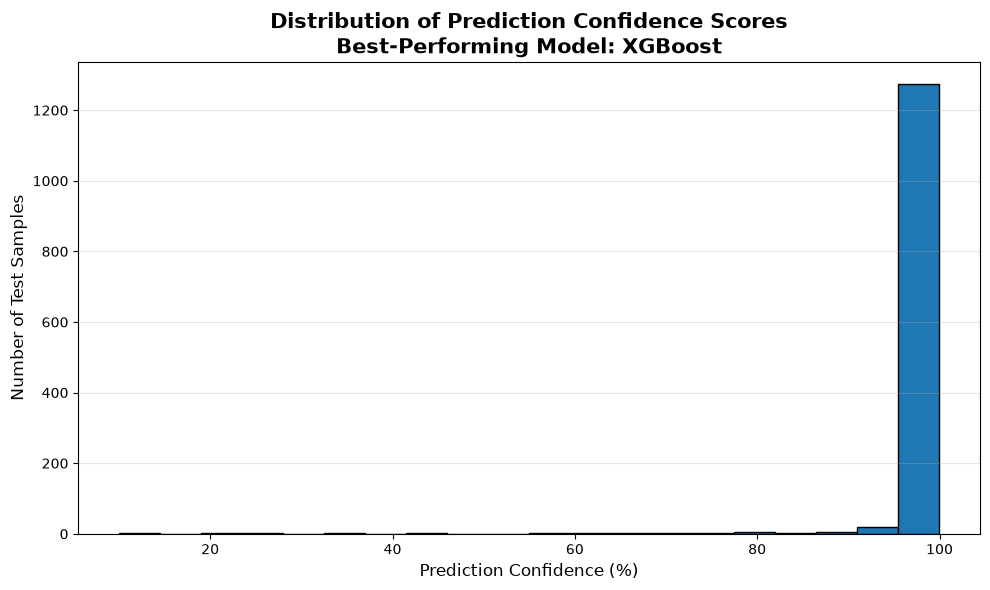


Saved: Prediction_Confidence_Distribution.png


In [19]:
# ============================================================
# CELL 19: PREDICTION CONFIDENCE DISTRIBUTION
# Best-Performing Model
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("PREDICTION CONFIDENCE DISTRIBUTION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Identify Best Model from Cell 17
# ------------------------------------------------------------

best_model_name = results_df.iloc[0]["Model"]

print("\nBest-Performing Model:", best_model_name)

# ------------------------------------------------------------
# 2. Select Corresponding Model
# ------------------------------------------------------------

if best_model_name == "Random Forest":

    best_model = rf_model
    X_confidence = X_test

elif best_model_name == "XGBoost":

    best_model = xgb_model
    X_confidence = X_test

elif best_model_name == "CatBoost":

    best_model = cat_model
    X_confidence = X_test

elif best_model_name == "TabNet":

    best_model = tabnet_model
    X_confidence = X_test.values.astype(np.float32)

elif best_model_name == "Logistic Regression":

    best_model = logistic_model
    X_confidence = X_test_lr

elif best_model_name == "EBM":

    best_model = ebm_model
    X_confidence = X_test

# ------------------------------------------------------------
# 3. Get Prediction Probabilities
# ------------------------------------------------------------

prediction_probabilities = best_model.predict_proba(
    X_confidence
)

# ------------------------------------------------------------
# 4. Get Maximum Probability for Each Test Sample
# ------------------------------------------------------------

confidence_scores = np.max(
    prediction_probabilities,
    axis=1
)

confidence_percent = confidence_scores * 100

# ------------------------------------------------------------
# 5. Print Basic Statistics
# ------------------------------------------------------------

print("\nNumber of Test Samples:", len(confidence_percent))

print(
    "Mean Confidence:",
    f"{np.mean(confidence_percent):.2f}%"
)

print(
    "Minimum Confidence:",
    f"{np.min(confidence_percent):.2f}%"
)

print(
    "Maximum Confidence:",
    f"{np.max(confidence_percent):.2f}%"
)

# ------------------------------------------------------------
# 6. Create Distribution Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    confidence_percent,
    bins=20,
    edgecolor="black"
)

plt.xlabel(
    "Prediction Confidence (%)",
    fontsize=12
)

plt.ylabel(
    "Number of Test Samples",
    fontsize=12
)

plt.title(
    f"Distribution of Prediction Confidence Scores\n"
    f"Best-Performing Model: {best_model_name}",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

# ------------------------------------------------------------
# 7. Save High-Resolution Figure
# ------------------------------------------------------------

plt.savefig(
    "Prediction_Confidence_Distribution.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print(
    "\nSaved: Prediction_Confidence_Distribution.png"
)

GLOBAL FEATURE IMPORTANCE USING SHAP

Best-Performing Model: XGBoost
SHAP data shape: (300, 13)

Creating SHAP Explainer...
SHAP array shape: (300, 13, 51)


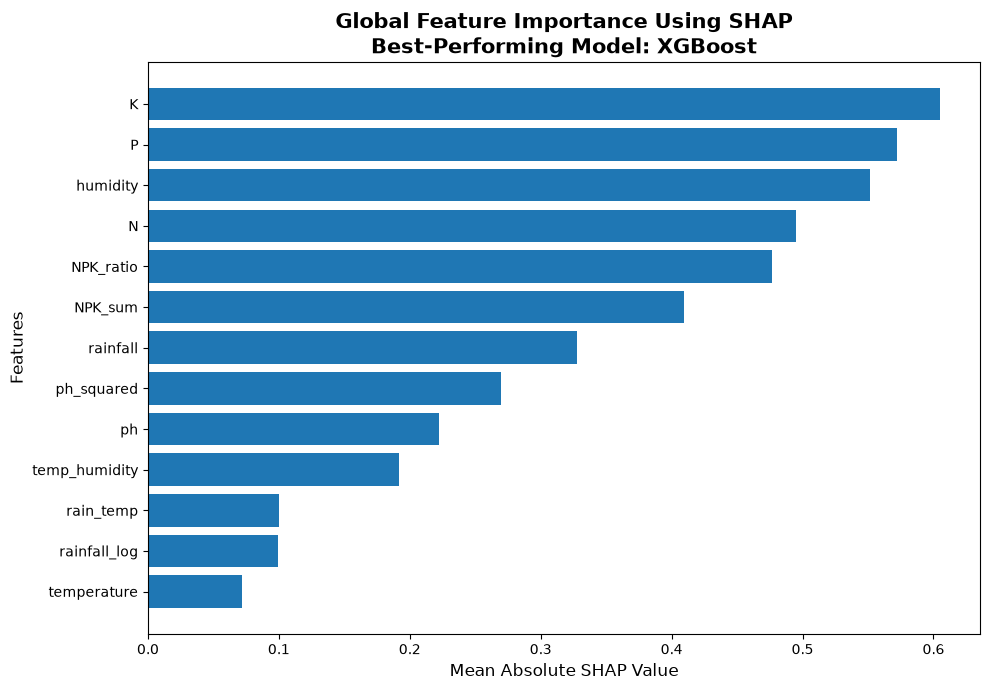


✅ Global SHAP Feature Importance created!
📁 Saved: SHAP_Global_Feature_Importance.png

Feature Importance Ranking:

1. K                    0.605273
2. P                    0.572127
3. humidity             0.551783
4. N                    0.495241
5. NPK_ratio            0.476801
6. NPK_sum              0.409816
7. rainfall             0.327635
8. ph_squared           0.269902
9. ph                   0.222300
10. temp_humidity        0.191428
11. rain_temp            0.100068
12. rainfall_log         0.099018
13. temperature          0.071873


In [20]:
# ============================================================
# CELL 20: GLOBAL FEATURE IMPORTANCE USING SHAP
# Best-Performing Model
# ============================================================

import shap
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("GLOBAL FEATURE IMPORTANCE USING SHAP")
print("=" * 70)

# ------------------------------------------------------------
# 1. Get Best Model
# ------------------------------------------------------------

best_model_name = results_df.iloc[0]["Model"]

print("\nBest-Performing Model:", best_model_name)

# ------------------------------------------------------------
# 2. Select Model and Test Data
# ------------------------------------------------------------

if best_model_name == "Random Forest":

    best_model = rf_model
    X_shap = X_test.copy()

elif best_model_name == "XGBoost":

    best_model = xgb_model
    X_shap = X_test.copy()

elif best_model_name == "CatBoost":

    best_model = cat_model
    X_shap = X_test.copy()

elif best_model_name == "TabNet":

    best_model = tabnet_model
    X_shap = X_test.copy()

elif best_model_name == "Logistic Regression":

    best_model = logistic_model
    X_shap = X_test_lr

elif best_model_name == "EBM":

    best_model = ebm_model
    X_shap = X_test.copy()

# ------------------------------------------------------------
# 3. Limit Samples to Avoid Kernel Restart
# ------------------------------------------------------------

if len(X_shap) > 300:

    X_shap = X_shap[:300]

print("SHAP data shape:", X_shap.shape)

# ------------------------------------------------------------
# 4. Create SHAP Explainer
# ------------------------------------------------------------

print("\nCreating SHAP Explainer...")

if best_model_name in [
    "Random Forest",
    "XGBoost",
    "CatBoost"
]:

    explainer = shap.TreeExplainer(best_model)

    shap_values = explainer.shap_values(X_shap)

elif best_model_name == "Logistic Regression":

    background = X_train_lr[:100]

    explainer = shap.LinearExplainer(
        best_model,
        background
    )

    shap_values = explainer.shap_values(X_shap)

elif best_model_name == "EBM":

    explainer = shap.Explainer(
        best_model.predict,
        X_shap
    )

    shap_values = explainer(X_shap)

elif best_model_name == "TabNet":

    explainer = shap.Explainer(
        best_model.predict_proba,
        X_shap
    )

    shap_values = explainer(X_shap)

# ------------------------------------------------------------
# 5. Handle Multiclass SHAP Output
# ------------------------------------------------------------

if isinstance(shap_values, list):

    # Multiclass output
    shap_array = np.array(shap_values)

    print("SHAP array shape:", shap_array.shape)

    # Average absolute SHAP values across all classes
    mean_shap = np.mean(
        np.abs(shap_array),
        axis=(0, 1)
    )

else:

    if hasattr(shap_values, "values"):

        shap_array = shap_values.values

    else:

        shap_array = np.array(shap_values)

    print("SHAP array shape:", shap_array.shape)

    if len(shap_array.shape) == 3:

        # samples × features × classes
        mean_shap = np.mean(
            np.abs(shap_array),
            axis=(0, 2)
        )

    else:

        # samples × features
        mean_shap = np.mean(
            np.abs(shap_array),
            axis=0
        )

# ------------------------------------------------------------
# 6. Feature Names
# ------------------------------------------------------------

feature_names = X_test.columns.tolist()

# ------------------------------------------------------------
# 7. Create Global Feature Importance
# ------------------------------------------------------------

importance_order = np.argsort(
    mean_shap
)[::-1]

sorted_features = [
    feature_names[i]
    for i in importance_order
]

sorted_importance = [
    mean_shap[i]
    for i in importance_order
]

# ------------------------------------------------------------
# 8. Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.barh(
    sorted_features[::-1],
    sorted_importance[::-1]
)

plt.xlabel(
    "Mean Absolute SHAP Value",
    fontsize=12
)

plt.ylabel(
    "Features",
    fontsize=12
)

plt.title(
    f"Global Feature Importance Using SHAP\n"
    f"Best-Performing Model: {best_model_name}",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

# ------------------------------------------------------------
# 9. Save Figure
# ------------------------------------------------------------

plt.savefig(
    "SHAP_Global_Feature_Importance.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\n✅ Global SHAP Feature Importance created!")
print(
    "📁 Saved: SHAP_Global_Feature_Importance.png"
)

# ------------------------------------------------------------
# 10. Print Ranking
# ------------------------------------------------------------

print("\nFeature Importance Ranking:\n")

for rank, (feature, importance) in enumerate(
    zip(sorted_features, sorted_importance),
    start=1
):

    print(
        f"{rank}. {feature:<20} "
        f"{importance:.6f}"
    )

PAPER-READY SHAP BEESWARM PLOT

Best-Performing Model: XGBoost
SHAP data shape: (300, 13)
Processed SHAP shape: (300, 13, 51)


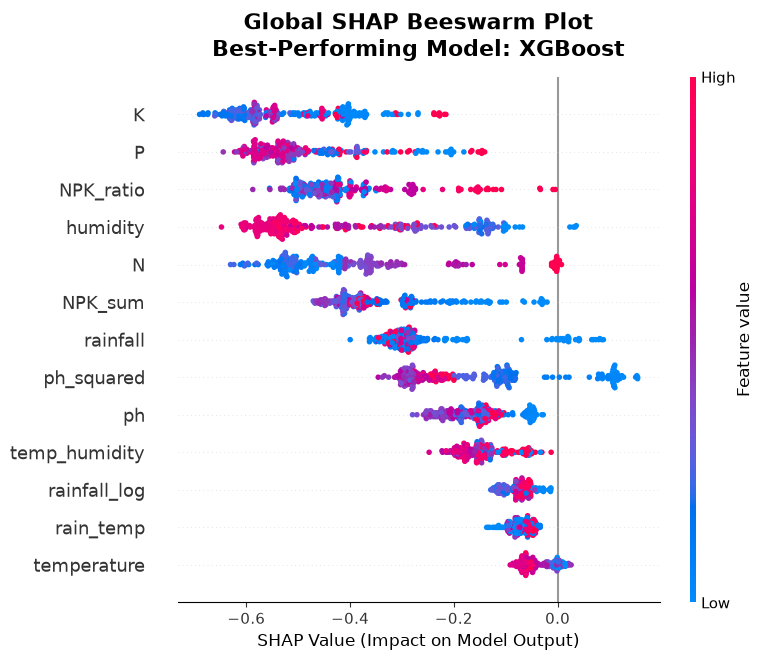


SHAP BEESWARM PLOT SUCCESSFULLY CREATED!

Saved as:
SHAP_Beeswarm_Paper.png


In [21]:

# CELL 21: PAPER-READY SHAP BEESWARM PLOT
# Global Explainability - Best Performing Model
# ============================================================

import shap
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("PAPER-READY SHAP BEESWARM PLOT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Get Best Model
# ------------------------------------------------------------

best_model_name = results_df.iloc[0]["Model"]

print("\nBest-Performing Model:", best_model_name)

# ------------------------------------------------------------
# 2. Select Model and Test Data
# ------------------------------------------------------------

if best_model_name == "Random Forest":

    best_model = rf_model
    X_shap = X_test.copy()

elif best_model_name == "XGBoost":

    best_model = xgb_model
    X_shap = X_test.copy()

elif best_model_name == "CatBoost":

    best_model = cat_model
    X_shap = X_test.copy()

elif best_model_name == "Logistic Regression":

    best_model = logistic_model
    X_shap = X_test_lr

elif best_model_name == "EBM":

    best_model = ebm_model
    X_shap = X_test.copy()

elif best_model_name == "TabNet":

    # TabNet can be expensive with SHAP
    X_shap = X_test.copy()

# ------------------------------------------------------------
# 3. Limit Samples
# ------------------------------------------------------------

if len(X_shap) > 300:

    X_shap_plot = X_shap.iloc[:300].copy()

else:

    X_shap_plot = X_shap.copy()

print("SHAP data shape:", X_shap_plot.shape)

# ------------------------------------------------------------
# 4. Create SHAP Values
# ------------------------------------------------------------

if best_model_name in [
    "Random Forest",
    "XGBoost",
    "CatBoost"
]:

    explainer = shap.TreeExplainer(best_model)

    shap_values = explainer.shap_values(
        X_shap_plot
    )

elif best_model_name == "Logistic Regression":

    explainer = shap.LinearExplainer(
        best_model,
        X_train_lr[:100]
    )

    shap_values = explainer.shap_values(
        X_shap_plot
    )

elif best_model_name == "EBM":

    explainer = shap.Explainer(
        best_model,
        X_shap_plot
    )

    shap_values = explainer(
        X_shap_plot
    )

elif best_model_name == "TabNet":

    # SHAP Kernel/Permutation explanation
    # using prediction function

    background = X_train_smote.iloc[:50].copy()

    explainer = shap.Explainer(
        best_model.predict_proba,
        background
    )

    shap_values = explainer(
        X_shap_plot.iloc[:100]
    )

    X_shap_plot = X_shap_plot.iloc[:100]

# ------------------------------------------------------------
# 5. Handle SHAP Output
# ------------------------------------------------------------

if isinstance(shap_values, list):

    # Older SHAP multiclass format
    shap_array = np.array(shap_values)

    print("SHAP array shape:", shap_array.shape)

    # Convert:
    # classes × samples × features
    # to:
    # samples × features × classes

    if shap_array.ndim == 3:

        shap_array = np.transpose(
            shap_array,
            (1, 2, 0)
        )

elif hasattr(shap_values, "values"):

    shap_array = shap_values.values

else:

    shap_array = np.array(shap_values)

print("Processed SHAP shape:", shap_array.shape)

# ------------------------------------------------------------
# 6. Create Beeswarm-Compatible SHAP Values
# ------------------------------------------------------------

if shap_array.ndim == 3:

    # Multiclass:
    # samples × features × classes

    # Average SHAP values across classes
    shap_beeswarm = np.mean(
        shap_array,
        axis=2
    )

else:

    shap_beeswarm = shap_array

# ------------------------------------------------------------
# 7. Feature Names
# ------------------------------------------------------------

feature_names = X_test.columns.tolist()

# ------------------------------------------------------------
# 8. Create SHAP Explanation Object
# ------------------------------------------------------------

shap_explanation = shap.Explanation(
    values=shap_beeswarm,
    data=X_shap_plot.values,
    feature_names=feature_names
)

# ------------------------------------------------------------
# 9. Paper-Ready Beeswarm Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

shap.plots.beeswarm(
    shap_explanation,
    max_display=len(feature_names),
    show=False
)

# ------------------------------------------------------------
# 10. Formatting
# ------------------------------------------------------------

plt.title(
    f"Global SHAP Beeswarm Plot\n"
    f"Best-Performing Model: {best_model_name}",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "SHAP Value (Impact on Model Output)",
    fontsize=12
)

plt.tight_layout()

# ------------------------------------------------------------
# 11. Save High-Resolution Figure
# ------------------------------------------------------------

plt.savefig(
    "SHAP_Beeswarm_Paper.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 70)
print("SHAP BEESWARM PLOT SUCCESSFULLY CREATED!")
print("=" * 70)

print("\nSaved as:")
print("SHAP_Beeswarm_Paper.png")

In [22]:
# ============================================================
# CELL 25: PAPER-READY LIME
# XGBoost - Crop Recommendation
# ============================================================

import numpy as np
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import HTML, display

print("=" * 70)
print("LIME LOCAL EXPLANATION - XGBOOST")
print("=" * 70)

# ------------------------------------------------------------
# 1. XGBoost Model
# ------------------------------------------------------------

model = xgb_model

# ------------------------------------------------------------
# 2. Training and Test Data
# ------------------------------------------------------------

X_train_lime = X_train_smote.copy()
X_test_lime = X_test.copy()

# Convert to NumPy
X_train_lime_array = np.asarray(X_train_lime)
X_test_lime_array = np.asarray(X_test_lime)

# ------------------------------------------------------------
# 3. Feature Names
# ------------------------------------------------------------

feature_names = X_test.columns.tolist()

# ------------------------------------------------------------
# 4. Create LIME Explainer
# ------------------------------------------------------------

lime_explainer_xgb = LimeTabularExplainer(
    training_data=X_train_lime_array,
    feature_names=feature_names,
    class_names=label_encoder.classes_.tolist(),
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

print("\nLIME Explainer created successfully.")

# ------------------------------------------------------------
# 5. Select Test Sample
# ------------------------------------------------------------

# Change this number to explain another test sample
sample_index = 200

sample = X_test_lime_array[sample_index]

# ------------------------------------------------------------
# 6. Prediction Function
# ------------------------------------------------------------

def get_class_probabilities(data):  # returns class probability array from trained model

    data = np.asarray(data)

    return model.predict_proba(data)

# ------------------------------------------------------------
# 7. Prediction
# ------------------------------------------------------------

prediction_probability = get_class_probabilities(
    sample.reshape(1, -1)
)[0]

predicted_class_index = np.argmax(
    prediction_probability
)

predicted_class = label_encoder.classes_[
    predicted_class_index
]

confidence = (
    prediction_probability[predicted_class_index] * 100
)

# ------------------------------------------------------------
# 8. Actual Class
# ------------------------------------------------------------
# Get actual crop name from encoded label

actual_class_index = int(np.asarray(y_test)[sample_index])

actual_class = label_encoder.classes_[actual_class_index]

# ------------------------------------------------------------
# 9. Print Prediction Information
# ------------------------------------------------------------

print("\n" + "-" * 70)

print("Test Sample Index:", sample_index)
print("Actual Crop:", actual_class)
print("Predicted Crop:", predicted_class)
print(f"Prediction Confidence: {confidence:.2f}%")

if str(actual_class) == str(predicted_class):

    print("Prediction Status: CORRECT")

else:

    print("Prediction Status: INCORRECT")

# ------------------------------------------------------------
# 10. Create LIME Explanation
# ------------------------------------------------------------

lime_exp_xgb = lime_explainer_xgb.explain_instance(
    sample,
    xgb_predict_probability,
    labels=[predicted_class_index],
    num_features=len(feature_names)
)

print("\nLIME explanation generated successfully.")

# ------------------------------------------------------------
# 11. Feature Contributions
# ------------------------------------------------------------

explanation_list = lime_exp_xgb.as_list(
    label=predicted_class_index
)

print("\n" + "=" * 70)
print("LIME FEATURE CONTRIBUTIONS - XGBOOST")
print("=" * 70)

for feature, weight in explanation_list:

    if weight >= 0:

        direction = "Supports prediction"

    else:

        direction = "Opposes prediction"

    print(
        f"{feature:35s} "
        f"{weight:+.4f}   "
        f"{direction}"
    )

# ------------------------------------------------------------
# 12. Generate Original LIME HTML
# ------------------------------------------------------------

lime_html_xgb = lime_exp_xgb.as_html(
    labels=[predicted_class_index],
    predict_proba=True,
    show_predicted_value=True
)

# ------------------------------------------------------------
# 13. Display Original LIME Visualization
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ORIGINAL LIME VISUALIZATION - XGBOOST")
print("=" * 70)

display(HTML(lime_html_xgb))

# ------------------------------------------------------------
# 14. Save HTML
# ------------------------------------------------------------

lime_exp_xgb.save_to_file(
    "LIME_XGBoost_Paper.html"
)

print("\n" + "=" * 70)
print("XGBOOST LIME SUCCESSFULLY COMPLETED")
print("=" * 70)

print("\nSaved as:")
print("LIME_XGBoost_Paper.html")

LIME LOCAL EXPLANATION - XGBOOST

LIME Explainer created successfully.

----------------------------------------------------------------------
Test Sample Index: 200
Actual Crop: onion
Predicted Crop: onion
Prediction Confidence: 99.82%
Prediction Status: CORRECT

LIME explanation generated successfully.

LIME FEATURE CONTRIBUTIONS - XGBOOST
N > 89.00                           +0.2071   Supports prediction
48.00 < P <= 60.00                  +0.0199   Supports prediction
82.52 < humidity <= 86.33           +0.0186   Supports prediction
5.54 < ph <= 6.15                   +0.0150   Supports prediction
NPK_sum > 200.00                    +0.0130   Supports prediction
rainfall > 1011.42                  -0.0118   Opposes prediction
0.74 < NPK_ratio <= 0.99            +0.0111   Supports prediction
30.69 < ph_squared <= 37.82         +0.0065   Supports prediction
K > 60.00                           -0.0050   Opposes prediction
1670.77 < temp_humidity <= 2158.46  +0.0045   Supports predictio


XGBOOST LIME SUCCESSFULLY COMPLETED

Saved as:
LIME_XGBoost_Paper.html


SHAP BEESWARM PLOT - RANDOM FOREST

SHAP data shape: (300, 13)
SHAP values calculated successfully.
Original SHAP shape: (300, 13, 51)
Processed SHAP shape: (300, 13)


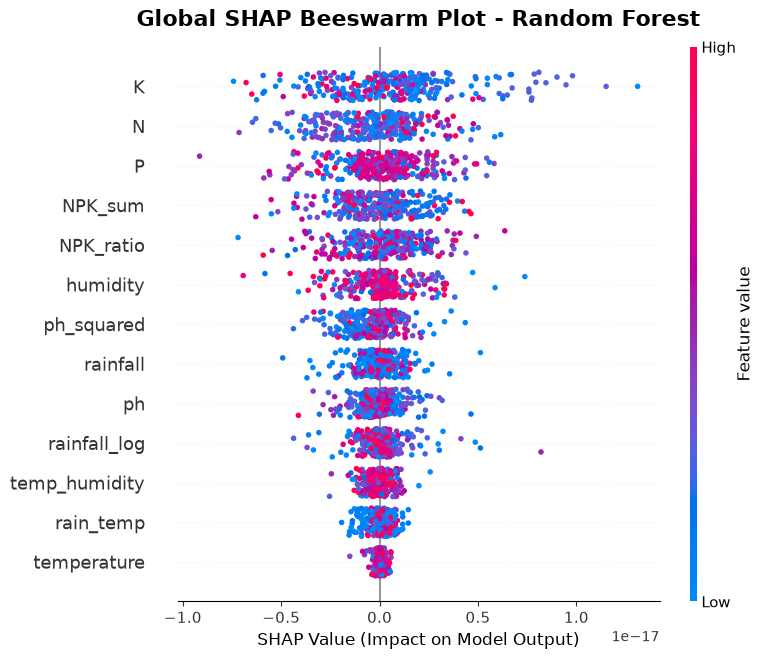


SHAP BEESWARM SUCCESSFULLY CREATED!

Saved as: SHAP_Beeswarm_RandomForest_Paper.png


In [23]:
# ============================================================
# CELL 23: SHAP BEESWARM PLOT
# Random Forest - Crop Recommendation
# ============================================================

import shap
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("SHAP BEESWARM PLOT - RANDOM FOREST")
print("=" * 70)

# ------------------------------------------------------------
# 1. Select Random Forest
# ------------------------------------------------------------

model = rf_model

# Use unseen test data
X_shap = X_test.copy()

# Limit samples to avoid Kernel Restart
if len(X_shap) > 300:
    X_shap = X_shap.iloc[:300].copy()

print("\nSHAP data shape:", X_shap.shape)

# ------------------------------------------------------------
# 2. Create Tree Explainer
# ------------------------------------------------------------

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_shap)

print("SHAP values calculated successfully.")

# ------------------------------------------------------------
# 3. Handle Multiclass SHAP Output
# ------------------------------------------------------------

if isinstance(shap_values, list):

    # Older SHAP versions
    shap_array = np.array(shap_values)

    print("Original SHAP shape:", shap_array.shape)

    # classes × samples × features
    # ↓
    # samples × features × classes

    if shap_array.ndim == 3:

        shap_array = np.transpose(
            shap_array,
            (1, 2, 0)
        )

else:

    if hasattr(shap_values, "values"):

        shap_array = shap_values.values

    else:

        shap_array = np.array(shap_values)

    print("Original SHAP shape:", shap_array.shape)

# ------------------------------------------------------------
# 4. Create Global SHAP Values
# ------------------------------------------------------------

if shap_array.ndim == 3:

    # Multiclass:
    # samples × features × classes

    shap_beeswarm = np.mean(
        shap_array,
        axis=2
    )

else:

    shap_beeswarm = shap_array

print(
    "Processed SHAP shape:",
    shap_beeswarm.shape
)

# ------------------------------------------------------------
# 5. Feature Names
# ------------------------------------------------------------

feature_names = X_test.columns.tolist()

# ------------------------------------------------------------
# 6. Create SHAP Explanation Object
# ------------------------------------------------------------

shap_explanation = shap.Explanation(
    values=shap_beeswarm,
    data=X_shap.values,
    feature_names=feature_names
)

# ------------------------------------------------------------
# 7. Create Paper-Ready Beeswarm
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

shap.plots.beeswarm(
    shap_explanation,
    max_display=len(feature_names),
    show=False
)

# ------------------------------------------------------------
# 8. Formatting
# ------------------------------------------------------------

plt.title(
    "Global SHAP Beeswarm Plot - Random Forest",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "SHAP Value (Impact on Model Output)",
    fontsize=12
)

plt.tight_layout()

# ------------------------------------------------------------
# 9. Save High Resolution
# ------------------------------------------------------------

plt.savefig(
    "SHAP_Beeswarm_RandomForest_Paper.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 70)
print("SHAP BEESWARM SUCCESSFULLY CREATED!")
print("=" * 70)

print(
    "\nSaved as: "
    "SHAP_Beeswarm_RandomForest_Paper.png"
)

In [24]:

# ============================================================
# CELL 24: PAPER-READY LIME
# Random Forest - Crop Recommendation
# ============================================================

import numpy as np
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import HTML, display

print("=" * 70)
print("LIME LOCAL EXPLANATION - RANDOM FOREST")
print("=" * 70)

# ------------------------------------------------------------
# 1. Random Forest Model
# ------------------------------------------------------------

model = rf_model

# ------------------------------------------------------------
# 2. Training and Test Data
# ------------------------------------------------------------

X_train_lime = X_train_smote.copy()
X_test_lime = X_test.copy()

# ------------------------------------------------------------
# 3. Convert Data to NumPy
# ------------------------------------------------------------

X_train_lime_array = np.asarray(X_train_lime)
X_test_lime_array = np.asarray(X_test_lime)

# ------------------------------------------------------------
# 4. Feature Names
# ------------------------------------------------------------

feature_names = X_test.columns.tolist()

# ------------------------------------------------------------
# 5. Create LIME Explainer
# ------------------------------------------------------------

lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime_array,
    feature_names=feature_names,
    class_names=label_encoder.classes_.tolist(),
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

print("\nLIME Explainer created successfully.")

# ------------------------------------------------------------
# 6. Select Test Sample
# ------------------------------------------------------------

# Change ONLY this number for another test sample
sample_index = 100

sample = X_test_lime_array[sample_index]

# ------------------------------------------------------------
# 7. Prediction Function
# ------------------------------------------------------------

def compute_crop_probabilities(data):  # wrapper for LIME tabular explainer compatibility

    data = np.asarray(data)

    return model.predict_proba(data)

# ------------------------------------------------------------
# 8. Model Prediction
# ------------------------------------------------------------

prediction_probability = compute_crop_probabilities(
    sample.reshape(1, -1)
)[0]

predicted_class_index = np.argmax(
    prediction_probability
)

predicted_class = label_encoder.classes_[
    predicted_class_index
]

confidence = (
    prediction_probability[predicted_class_index] * 100
)

# ------------------------------------------------------------
# 9. Actual Class
# ------------------------------------------------------------

# Works for both NumPy array and Pandas Series

# Get actual crop name from encoded label

actual_class_index = int(np.asarray(y_test)[sample_index])

actual_class = label_encoder.classes_[actual_class_index]

# ------------------------------------------------------------
# 10. Print Prediction Information
# ------------------------------------------------------------

print("\n" + "-" * 70)

print("Test Sample Index:", sample_index)
print("Actual Crop:", actual_class)
print("Predicted Crop:", predicted_class)
print(f"Prediction Confidence: {confidence:.2f}%")

if str(actual_class) == str(predicted_class):

    print("Prediction Status: CORRECT")

else:

    print("Prediction Status: INCORRECT")

# ------------------------------------------------------------
# 11. Create LIME Explanation
# ------------------------------------------------------------

lime_exp = lime_explainer.explain_instance(
    sample,
    predict_probability,
    labels=[predicted_class_index],
    num_features=len(feature_names)
)

print("\nLIME explanation generated successfully.")

# ------------------------------------------------------------
# 12. Get Feature Contributions
# ------------------------------------------------------------

explanation_list = lime_exp.as_list(
    label=predicted_class_index
)

print("\n" + "=" * 70)
print("LIME FEATURE CONTRIBUTIONS")
print("=" * 70)

for feature, weight in explanation_list:

    if weight >= 0:

        direction = "Supports prediction"

    else:

        direction = "Opposes prediction"

    print(
        f"{feature:35s} "
        f"{weight:+.4f}   "
        f"{direction}"
    )

# ------------------------------------------------------------
# 13. Generate Original LIME HTML
# ------------------------------------------------------------

lime_html = lime_exp.as_html(
    labels=[predicted_class_index],
    predict_proba=True,
    show_predicted_value=True
)

# ------------------------------------------------------------
# 14. Display LIME Visualization
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ORIGINAL LIME VISUALIZATION")
print("=" * 70)

display(HTML(lime_html))

# ------------------------------------------------------------
# 15. Save HTML
# ------------------------------------------------------------

lime_exp.save_to_file(
    "LIME_RandomForest_Paper.html"
)

print("\n" + "=" * 70)
print("LIME SUCCESSFULLY COMPLETED")
print("=" * 70)

print("\nSaved file:")
print("LIME_RandomForest_Paper.html")

LIME LOCAL EXPLANATION - RANDOM FOREST

LIME Explainer created successfully.


c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



----------------------------------------------------------------------
Test Sample Index: 100
Actual Crop: sorghum
Predicted Crop: sorghum
Prediction Confidence: 100.00%
Prediction Status: CORRECT

LIME explanation generated successfully.

LIME FEATURE CONTRIBUTIONS
156.00 < NPK_sum <= 200.00          +0.0101   Supports prediction
60.00 < N <= 89.00                  +0.0094   Supports prediction
28.00 < P <= 48.00                  +0.0085   Supports prediction
20.00 < K <= 40.00                  +0.0081   Supports prediction
0.74 < NPK_ratio <= 0.99            +0.0077   Supports prediction
ph_squared <= 30.69                 +0.0064   Supports prediction
ph <= 5.54                          +0.0063   Supports prediction
temperature > 28.55                 +0.0026   Supports prediction
temp_humidity > 2361.24             +0.0024   Supports prediction
207.55 < rainfall <= 1011.42        +0.0020   Supports prediction
5.34 < rainfall_log <= 6.91         +0.0020   Supports prediction
humidi


LIME SUCCESSFULLY COMPLETED

Saved file:
LIME_RandomForest_Paper.html


In [25]:
# ============================================================
# TRAIN / TEST SAMPLE INDEX
# ============================================================

print("Training sample indices:")
print(X_train.index[:20].tolist())

print("\nTesting sample indices:")
print(X_test.index[:20].tolist())

Training sample indices:
[2219, 2636, 5338, 6539, 6349, 6092, 1142, 4655, 1228, 2987, 3651, 4267, 437, 3249, 5107, 2340, 2020, 6393, 1104, 6284]

Testing sample indices:
[5784, 2112, 5687, 1491, 379, 2697, 487, 2589, 6220, 2447, 5826, 4055, 601, 1864, 4573, 2852, 2568, 5682, 3575, 4849]
